# 🤖 Automated Code Documentation & Bug Report Analysis
## v3 — GCP A100 Edition | CodeT5-small Baseline (Spring 2026)
**MS Data Science & AI Capstone | FIU**

---
### Model: CodeT5-small

| Model | HF ID | Arch | Params | Tokenizer | LoRA |
|-------|--------|------|--------|-----------|------|
| **CodeT5-small** | `Salesforce/codet5-small` | Enc-Dec T5 | 60M | `RobertaTokenizer` | No |

> CodeT5+ 220M (full FT) and CodeT5+ 220M + LoRA will be added in Fall 2026 for the three-way comparison.

### Pipeline
```
0. GCP Setup & Verification
1. Data Loading, EDA & Quality Filtering (PyPlus-style)
2. Metric Suite (BLEU-4, ROUGE-L, METEOR, CodeBLEU)
3. Model Definition — CodeT5-small
4. Training
5. Results & Analysis
6. Full Fine-Tuning on Combined Dataset
7. Final Evaluation & Inference Demo
```

**Paper refs:** Shaalan & Zakaria 2023 · Wang et al. 2021 (CodeT5) · Hu et al. 2021 (LoRA)


---
## ⚙️ SECTION 0 — GCP Setup & Verification

In [1]:
# ── Install packages ────────────────────────────────────────────────────────

!pip install -q codebleu rouge_score sacrebleu evaluate sentencepiece

import os, json, re, ast, random, warnings, textwrap, time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from collections import Counter, defaultdict
from tqdm.auto import tqdm

import torch
from datasets import load_dataset, DatasetDict, Dataset, concatenate_datasets

# ── IMPORTANT: Use the correct tokenizer per model ─────────────────────────
# CodeT5-small / codet5-base  → RobertaTokenizer (code-specific BPE)
# CodeT5+ variants            → AutoTokenizer
from transformers import (
    RobertaTokenizer,           # For original CodeT5 models
    AutoTokenizer,              # For CodeT5+ models
    T5ForConditionalGeneration, # For original CodeT5 models
    AutoModelForSeq2SeqLM,      # For CodeT5+ models
    Seq2SeqTrainer,
    Seq2SeqTrainingArguments,
    DataCollatorForSeq2Seq,
    EarlyStoppingCallback,
    get_cosine_schedule_with_warmup,
)
from peft import LoraConfig, get_peft_model, TaskType, PeftModel
import evaluate
import nltk
for pkg in ['punkt', 'punkt_tab', 'wordnet']:
    nltk.download(pkg, quiet=True)

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 100

# ── GPU Check ──────────────────────────────────────────────────────────────
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Device: {DEVICE}')
if DEVICE == 'cuda':
    gpu_name = torch.cuda.get_device_name(0)
    vram_gb  = torch.cuda.get_device_properties(0).total_memory / 1e9
    print(f'GPU:    {gpu_name}')
    print(f'VRAM:   {vram_gb:.1f} GB')
    if 'A100' in gpu_name:
        print('✅ A100 confirmed — running full dataset mode')
    elif 'T4' in gpu_name:
        print('⚠️  T4 detected — reduce train sizes in CFG if you hit OOM')

# ── Reproducibility ────────────────────────────────────────────────────────
SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
if DEVICE == 'cuda': torch.cuda.manual_seed_all(SEED)

print('\n✅ Environment ready')

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 100.8/100.8 kB 5.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 5.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 546.2/546.2 kB 20.5 MB/s eta 0:00:00
Device: cuda
GPU:    Tesla T4
VRAM:   15.6 GB
⚠️  T4 detected — reduce train sizes in CFG if you hit OOM

✅ Environment ready


In [2]:
# ── Global Config ──────────────────────────────────────────────────────────
# A100 (40GB) can handle much larger batches and datasets than T4 (15GB)
# Adjust the _SIZE values down if running on T4

CFG = {
    # ── Dataset sizes ────────────────────────────────────────
    # A100: use these. T4: halve them.
    'csn_train_size':    50000,   # CodeSearchNet train samples
    'csn_val_size':       15000,
    'csn_test_size':      15000,
    'gh_size':           10000,   # GitHub Issues total

    # ── Tokenization ────────────────────────────────────────
    # 512 input matches original CodeT5 paper setup
    'max_input_len':   512,
    'max_target_len':  128,

    # ── Comparison run ──────────────────────────────────────
    # On A100 we can afford larger comparison subsets
    'cmp_train_size':  15000,     # per model during comparison
    'cmp_val_size':     1500,
    'cmp_epochs':          3,     # 3 epochs gives reliable signal
    'cmp_batch':          16,     # A100: 16. T4: 8.
    'cmp_lr':          5e-5,

    # ── Full fine-tuning ────────────────────────────────────
    'ft_epochs':           2,
    'ft_batch':           32,     # A100: 16. T4: 8.
    'ft_lr':           3e-5,
    'warmup_ratio':     0.10,
    'weight_decay':     0.01,
    'grad_accum':          1,     # effective batch = 32
    'early_stop_patience': 2,

    # ── LoRA config ─────────────────────────────────────────
    'lora_r':         16,
    'lora_alpha':     32,
    'lora_dropout':  0.10,
    # Target the query and value projections in attention
    'lora_targets': ['q', 'v'],

    # ── Paths ───────────────────────────────────────────────
    'output_dir': '/content/outputs',
    'model_dir':  '/content/best_model',
    'data_cache': '/content/data_cache',
}

for d in [CFG['output_dir'], CFG['model_dir'], CFG['data_cache']]:
    os.makedirs(d, exist_ok=True)

print('Config summary:')
print(f'  CSN train:    {CFG["csn_train_size"]:,}')
print(f'  GH Issues:    {CFG["gh_size"]:,}')
print(f'  Cmp batch:    {CFG["cmp_batch"]} (effective: {CFG["cmp_batch"]})')
print(f'  FT batch:     {CFG["ft_batch"]} × {CFG["grad_accum"]} accum = {CFG["ft_batch"]*CFG["grad_accum"]} effective')
print('✅ Config ready')

Config summary:
  CSN train:    50,000
  GH Issues:    10,000
  Cmp batch:    16 (effective: 16)
  FT batch:     32 × 1 accum = 32 effective
✅ Config ready


---
## 📊 SECTION 1 — Data Loading, EDA & Quality Filtering

In [3]:
# ── 1A: Load datasets ──────────────────────────────────────────────────────
print('Loading CodeSearchNet (Python)...')
csn_raw = load_dataset('code_search_net', 'python')  # removed trust_remote_code
print(f'  Train {len(csn_raw["train"]):,} | Val {len(csn_raw["validation"]):,} | Test {len(csn_raw["test"]):,}')

print('\nLoading GitHub Issues...')
# Use sharjeelyunus dataset — verified working on HF Hub
gh_raw = load_dataset('sharjeelyunus/github-issues-dataset')
print(f'  Loaded: {list(gh_raw.keys())}')

# Detect field names
GH_SPLIT = list(gh_raw.keys())[0]
sample_gh = gh_raw[GH_SPLIT][0]
print('  Fields:', list(sample_gh.keys()))

GH_TITLE_FIELD = next((f for f in ['title','issue_title','name'] if f in sample_gh), None)
GH_BODY_FIELD  = next((f for f in ['body','issue_body','text','description'] if f in sample_gh), None)
print(f'  title field: "{GH_TITLE_FIELD}" | body field: "{GH_BODY_FIELD}"')

# Preview CSN fields
csn_sample = csn_raw['train'][0]
print('\nCodeSearchNet fields:', list(csn_sample.keys()))

Loading CodeSearchNet (Python)...


README.md: 0.00B [00:00, ?B/s]

python/train-00000-of-00001.parquet:   0%|          | 0.00/522M [00:00<?, ?B/s]

python/test-00000-of-00001.parquet:   0%|          | 0.00/28.7M [00:00<?, ?B/s]

python/validation-00000-of-00001.parquet:   0%|          | 0.00/30.7M [00:00<?, ?B/s]

...

  Train 412,178 | Val 23,107 | Test 22,176

Loading GitHub Issues...


README.md: 0.00B [00:00, ?B/s]

github_issues_dataset.parquet:   0%|          | 0.00/139M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/114073 [00:00<?, ? examples/s]

  Loaded: ['train']
  Fields: ['id', 'repo', 'title', 'body', 'labels', 'priority', 'severity']
  title field: "title" | body field: "body"

CodeSearchNet fields: ['repository_name', 'func_path_in_repository', 'func_name', 'whole_func_string', 'language', 'func_code_string', 'func_code_tokens', 'func_documentation_string', 'func_documentation_tokens', 'split_name', 'func_code_url']


In [4]:
# ── 1B: EDA — CodeSearchNet ────────────────────────────────────────────────
def eda_csn(dataset, n=8000):
    n = min(n, len(dataset))
    records = dataset.select(range(n))
    rows = []
    for r in tqdm(records, desc='EDA CSN', leave=False):
        code = r.get('whole_func_string', '')
        doc  = r.get('func_documentation_string', '')
        try:
            tree = ast.parse(code)
            all_ids    = [nd.id for nd in ast.walk(tree) if isinstance(nd, ast.Name)]
            n_args     = sum(1 for nd in ast.walk(tree) if isinstance(nd, ast.arg))
            has_return = any(isinstance(nd, ast.Return) for nd in ast.walk(tree))
        except Exception:
            all_ids, n_args, has_return = [], 0, False
        rows.append({
            'code_chars':     len(code),
            'code_lines':     code.count('\n') + 1,
            'doc_words':      len(doc.split()),
            'n_identifiers':  len(all_ids),
            'n_unique_ids':   len(set(all_ids)),
            'n_args':         n_args,
            'has_return':     has_return,
            'has_doc':        len(doc.strip()) > 10,
            'has_inline':     bool(re.search(r'(?<!:)#\s+\w', code)),
            'has_param_doc':  bool(re.search(r'(Args:|:param |Parameters)', doc)),
            'has_return_doc': bool(re.search(r'(Returns:|:return)', doc)),
        })
    return pd.DataFrame(rows)

csn_eda = eda_csn(csn_raw['train'])
print('=== CodeSearchNet EDA ===')
print(csn_eda[['code_chars','code_lines','doc_words','n_identifiers']].describe().round(1))
print(f'\nDocstring coverage:       {csn_eda["has_doc"].mean()*100:.1f}%')
print(f'Has inline comments:      {csn_eda["has_inline"].mean()*100:.1f}%')
print(f'Has structured param doc: {csn_eda["has_param_doc"].mean()*100:.1f}%')
print(f'Has return doc:           {csn_eda["has_return_doc"].mean()*100:.1f}%')

EDA CSN:   0%|          | 0/8000 [00:00<?, ?it/s]

=== CodeSearchNet EDA ===
       code_chars  code_lines  doc_words  n_identifiers
count      8000.0      8000.0     8000.0         8000.0
mean        981.4        24.5       34.2           23.8
std        1314.6        28.1       52.6           33.0
min         100.0         3.0        1.0            0.0
25%         371.8        10.0        9.0            8.0
50%         615.0        17.0       19.0           14.0
75%        1110.0        29.0       42.0           27.0
max       24543.0       557.0     1864.0          570.0

Docstring coverage:       99.7%
Has inline comments:      30.7%
Has structured param doc: 31.8%
Has return doc:           19.0%


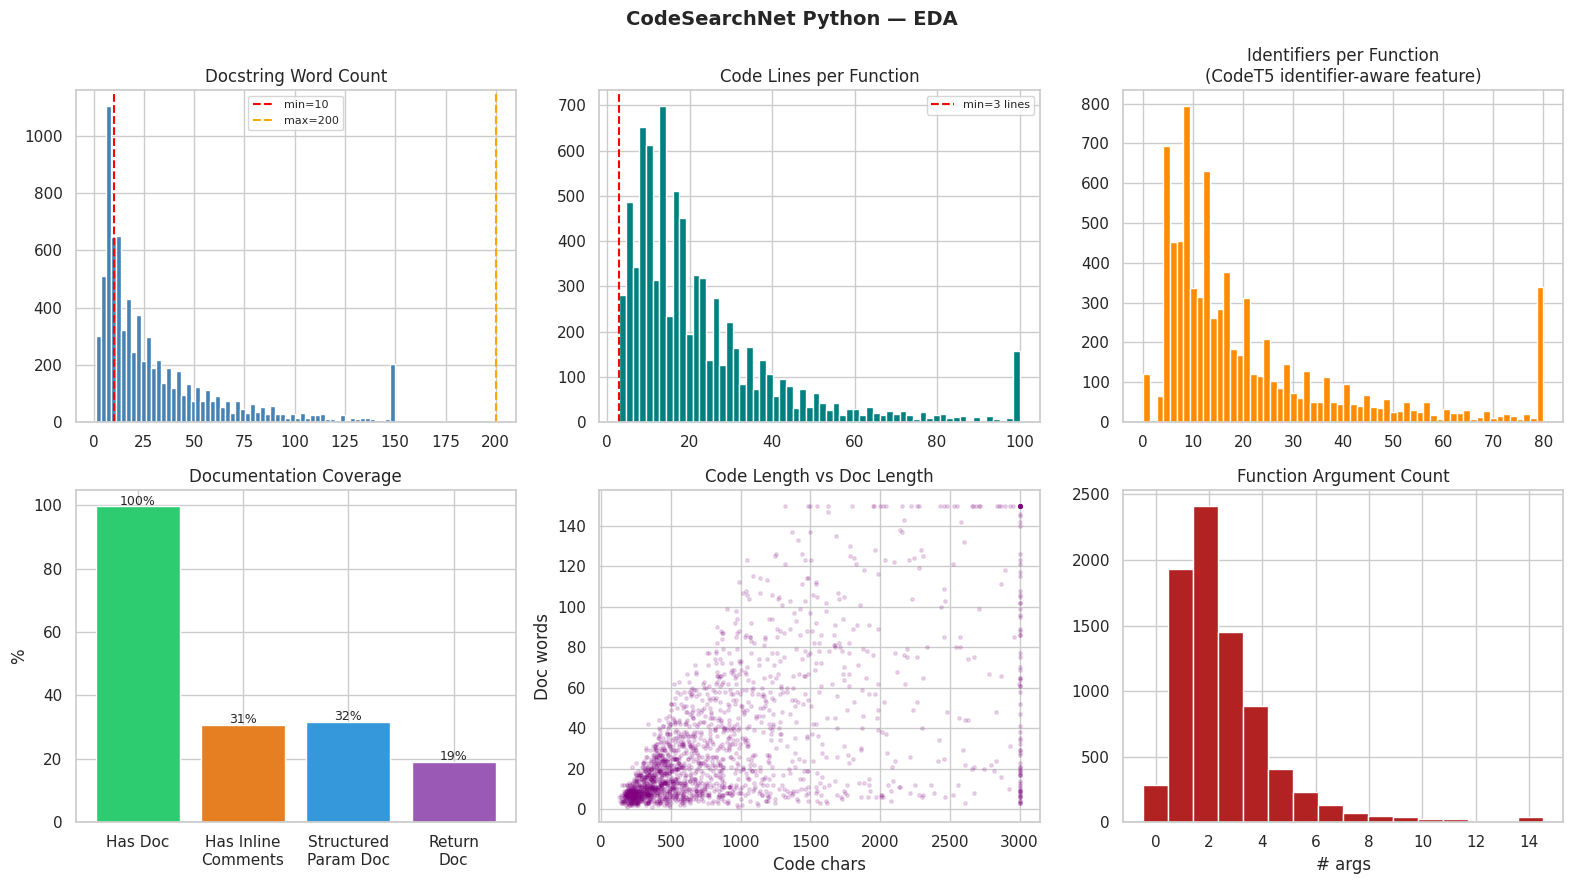

In [5]:
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
fig.suptitle('CodeSearchNet Python — EDA', fontsize=14, fontweight='bold')

# Docstring words
axes[0,0].hist(csn_eda['doc_words'].clip(0,150), bins=60, color='steelblue', edgecolor='white')
axes[0,0].axvline(10,  color='red',    ls='--', lw=1.5, label='min=10')
axes[0,0].axvline(200, color='orange', ls='--', lw=1.5, label='max=200')
axes[0,0].set_title('Docstring Word Count'); axes[0,0].legend(fontsize=8)

# Code lines
axes[0,1].hist(csn_eda['code_lines'].clip(0,100), bins=60, color='teal', edgecolor='white')
axes[0,1].axvline(3, color='red', ls='--', lw=1.5, label='min=3 lines')
axes[0,1].set_title('Code Lines per Function'); axes[0,1].legend(fontsize=8)

# Identifier count — key CodeT5 identifier-aware feature
axes[0,2].hist(csn_eda['n_identifiers'].clip(0,80), bins=60, color='darkorange', edgecolor='white')
axes[0,2].set_title('Identifiers per Function\n(CodeT5 identifier-aware feature)')

# Documentation quality breakdown
cats   = ['Has Doc', 'Has Inline\nComments', 'Structured\nParam Doc', 'Return\nDoc']
pcts   = [csn_eda[c].mean() for c in ['has_doc','has_inline','has_param_doc','has_return_doc']]
colors = ['#2ecc71','#e67e22','#3498db','#9b59b6']
bars   = axes[1,0].bar(cats, [p*100 for p in pcts], color=colors)
axes[1,0].set_title('Documentation Coverage'); axes[1,0].set_ylabel('%')
for b, p in zip(bars, pcts):
    axes[1,0].text(b.get_x()+b.get_width()/2, b.get_height()+0.5, f'{p*100:.0f}%', ha='center', fontsize=9)

# Code chars vs doc words
sample_mask = csn_eda.sample(min(2000, len(csn_eda)), random_state=42).index
axes[1,1].scatter(csn_eda.loc[sample_mask,'code_chars'].clip(0,3000),
                   csn_eda.loc[sample_mask,'doc_words'].clip(0,150),
                   alpha=0.15, s=6, color='purple')
axes[1,1].set_title('Code Length vs Doc Length')
axes[1,1].set_xlabel('Code chars'); axes[1,1].set_ylabel('Doc words')

# Args distribution
axes[1,2].hist(csn_eda['n_args'].clip(0,15), bins=16, color='firebrick', edgecolor='white', align='left')
axes[1,2].set_title('Function Argument Count')
axes[1,2].set_xlabel('# args')

plt.tight_layout()
plt.savefig(f"{CFG['output_dir']}/eda_csn.png", dpi=120, bbox_inches='tight')
plt.show()

In [6]:
# ── 1C: EDA — GitHub Issues ────────────────────────────────────────────────
def eda_gh(dataset, n=5000):
    n = min(n, len(dataset))
    records = dataset.select(range(n))
    rows = []
    for r in tqdm(records, desc='EDA GH', leave=False):
        title = str(r.get(GH_TITLE_FIELD, '') or '')
        body  = str(r.get(GH_BODY_FIELD,  '') or '')
        label = r.get('label', r.get('labels', ''))
        if isinstance(label, list): label = label[0] if label else ''
        rows.append({
            'title_words':      len(title.split()),
            'body_words':       len(body.split()),
            'has_traceback':    'traceback' in body.lower(),
            'has_error_msg':    bool(re.search(r'\bError:\b|\bException:\b', body)),
            'has_code_block':   '```' in body,
            'has_repro_steps':  'reproduce' in body.lower() or 'steps to' in body.lower(),
            'label':            str(label).strip().lower()[:30],
        })
    return pd.DataFrame(rows)

gh_eda = eda_gh(gh_raw[GH_SPLIT])
print('=== GitHub Issues EDA ===')
print(gh_eda[['title_words','body_words']].describe().round(1))
print(f'\nHas traceback:    {gh_eda["has_traceback"].mean()*100:.1f}%')
print(f'Has error msg:    {gh_eda["has_error_msg"].mean()*100:.1f}%')
print(f'Has code block:   {gh_eda["has_code_block"].mean()*100:.1f}%')
print(f'Has repro steps:  {gh_eda["has_repro_steps"].mean()*100:.1f}%')
print(f'\nTop labels:\n{gh_eda["label"].value_counts().head(10)}')

EDA GH:   0%|          | 0/5000 [00:00<?, ?it/s]

=== GitHub Issues EDA ===
       title_words  body_words
count       5000.0      5000.0
mean           7.5       181.8
std            3.3       338.8
min            1.0         0.0
25%            5.0        61.0
50%            7.0       123.0
75%            9.0       220.0
max           26.0     18481.0

Has traceback:    4.9%
Has error msg:    0.1%
Has code block:   48.3%
Has repro steps:  8.3%

Top labels:
label
needsinvestigation                298
site-support-request              226
request                           224
bug,auto-transferred,priority:    193
auto-transferred,priority: nor     91
compiler/runtime                   79
bug                                74
suggestion,awaiting more feedb     65
mobile                             55
for second edition                 48
Name: count, dtype: int64


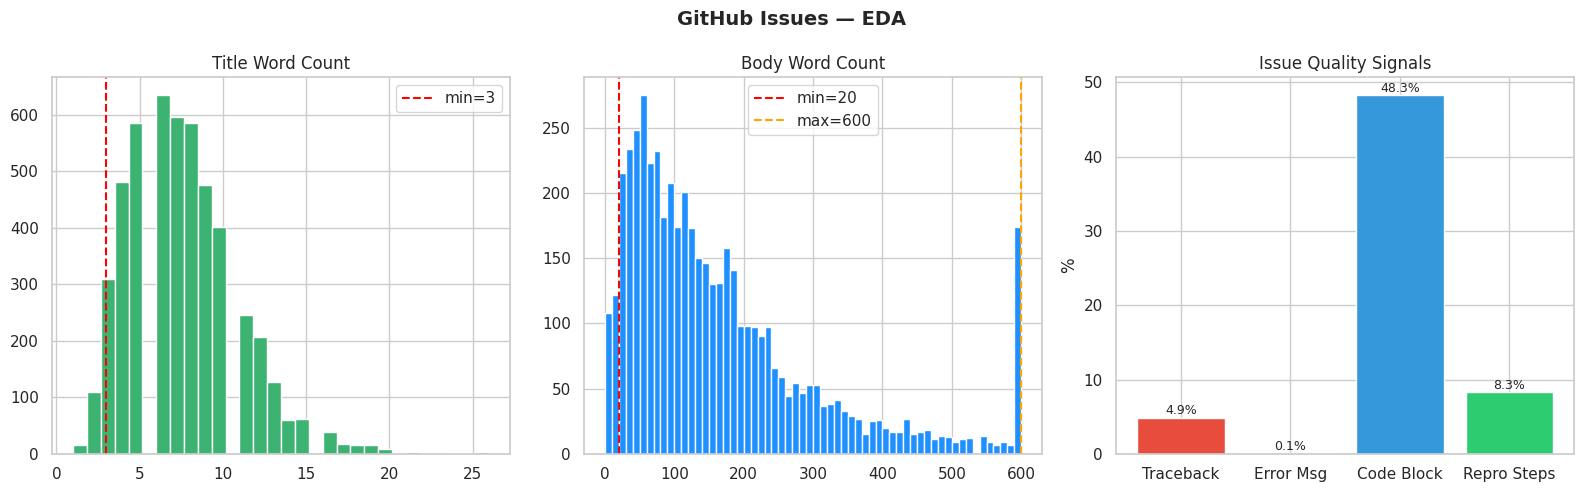

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('GitHub Issues — EDA', fontsize=14, fontweight='bold')

axes[0].hist(gh_eda['title_words'].clip(0,30), bins=30, color='mediumseagreen', edgecolor='white')
axes[0].axvline(3, color='red', ls='--', label='min=3'); axes[0].legend()
axes[0].set_title('Title Word Count')

axes[1].hist(gh_eda['body_words'].clip(0,600), bins=60, color='dodgerblue', edgecolor='white')
axes[1].axvline(20,  color='red',    ls='--', label='min=20')
axes[1].axvline(600, color='orange', ls='--', label='max=600')
axes[1].legend(); axes[1].set_title('Body Word Count')

sig_labels = ['Traceback', 'Error Msg', 'Code Block', 'Repro Steps']
sig_pcts   = [gh_eda[c].mean() for c in ['has_traceback','has_error_msg','has_code_block','has_repro_steps']]
axes[2].bar(sig_labels, [p*100 for p in sig_pcts], color=['#e74c3c','#e67e22','#3498db','#2ecc71'])
axes[2].set_title('Issue Quality Signals'); axes[2].set_ylabel('%')
for i, p in enumerate(sig_pcts):
    axes[2].text(i, p*100+0.5, f'{p*100:.1f}%', ha='center', fontsize=9)

plt.tight_layout()
plt.savefig(f"{CFG['output_dir']}/eda_github.png", dpi=120)
plt.show()

In [8]:
# ── 1D: Quality Filtering ──────────────────────────────────────────────────
def is_quality_csn(ex):
    doc  = ex.get('func_documentation_string', '') or ''
    code = ex.get('whole_func_string', '') or ''
    if not doc.strip() or not code.strip():
        return False
    dw = len(doc.split())
    if dw < 10 or dw > 200:
        return False
    cc = len(code)
    if cc < 50 or cc > 8000:
        return False
    if code.count('\n') < 2:   # at least 3 lines
        return False
    if doc.strip() in ('...', 'pass', 'TODO', 'todo'):
        return False
    # Need at least a few identifiers — low-identifier functions add little signal
    try:
        tree = ast.parse(code)
        n_ids = sum(1 for nd in ast.walk(tree) if isinstance(nd, ast.Name))
        if n_ids < 3:
            return False
    except Exception:
        pass  # unparseable code still allowed
    return True


def is_quality_gh(ex):
    title = str(ex.get(GH_TITLE_FIELD, '') or '')
    body  = str(ex.get(GH_BODY_FIELD,  '') or '')
    tw, bw = len(title.split()), len(body.split())
    if tw < 3 or bw < 20 or bw > 600:
        return False
    # Reject single-word/generic titles
    if title.lower().strip() in {'bug', 'fix', 'issue', 'error', 'help', 'question', 'problem'}:
        return False
    return True


print('Filtering CodeSearchNet...')
t0 = time.time()
csn_filtered = csn_raw['train'].filter(is_quality_csn, num_proc=4)
print(f'  {len(csn_raw["train"]):,} → {len(csn_filtered):,} kept ({len(csn_filtered)/len(csn_raw["train"])*100:.1f}%) [{time.time()-t0:.1f}s]')

print('Filtering GitHub Issues...')
t0 = time.time()
gh_filtered = gh_raw[GH_SPLIT].filter(is_quality_gh, num_proc=4)
print(f'  {len(gh_raw[GH_SPLIT]):,} → {len(gh_filtered):,} kept ({len(gh_filtered)/len(gh_raw[GH_SPLIT])*100:.1f}%) [{time.time()-t0:.1f}s]')

Filtering CodeSearchNet...


Filter (num_proc=4):   0%|          | 0/412178 [00:00<?, ? examples/s]

  412,178 → 286,152 kept (69.4%) [195.7s]
Filtering GitHub Issues...


Filter (num_proc=4):   0%|          | 0/114073 [00:00<?, ? examples/s]

  114,073 → 100,947 kept (88.5%) [4.9s]


In [9]:
# ── 1E: PyPlus-style Target Enrichment ────────────────────────────────────
# Aligned with Shaalan & Zakaria (2023): rather than predicting just the
# docstring, the model learns to generate an enriched description that
# includes a block-level summary of the code's logic (ConcodePlus task).

def extract_logic_summary(code: str) -> str:
    """Extract a brief block-level description from code structure."""
    lines = code.strip().split('\n')
    blocks = []
    kw_map = {
        'if ':     'conditional check',
        'elif ':   'alternative condition',
        'for ':    'iterates over',
        'while ':  'loops while',
        'try:':    'handles exceptions',
        'with ':   'context manager',
        'return ': 'returns',
        'raise ':  'raises',
        'yield ':  'yields',
    }
    seen = set()
    for line in lines:
        s = line.strip()
        for kw, label in kw_map.items():
            if s.startswith(kw) and label not in seen:
                tail = s[len(kw):].split('(')[0].split(':')[0][:30].strip()
                blocks.append(f'{label} {tail}'.strip())
                seen.add(label)
                break
    return ('; '.join(blocks[:4]) if blocks else 'single operation')


def add_pyplus_target(example):
    """Enrich the target with PyPlus-style logic summary."""
    doc  = (example.get('func_documentation_string', '') or '').strip()
    code = example.get('whole_func_string', '') or ''
    logic = extract_logic_summary(code)
    example['pyplus_target'] = f'{doc} | Logic: {logic}'
    return example


# Demo
demo = csn_filtered[0]
demo_enriched = add_pyplus_target(dict(demo))
print('=== PyPlus Enrichment Example ===')
print(f'Original docstring:\n  {demo["func_documentation_string"][:150]}')
print(f'\nEnriched target:\n  {demo_enriched["pyplus_target"][:200]}')

print('\nApplying to all filtered CSN data...')
csn_enriched = csn_filtered.map(add_pyplus_target, num_proc=4)

# Build final splits
n_train = min(CFG['csn_train_size'], len(csn_enriched))
csn_train_ds = csn_enriched.shuffle(seed=SEED).select(range(n_train))

def filter_and_enrich_split(split_ds):
    filtered = split_ds.filter(is_quality_csn, num_proc=4)
    return filtered.map(add_pyplus_target, num_proc=4)

csn_val_enriched  = filter_and_enrich_split(csn_raw['validation'])
csn_test_enriched = filter_and_enrich_split(csn_raw['test'])
csn_val_ds   = csn_val_enriched.shuffle(seed=SEED).select(range(min(CFG['csn_val_size'],  len(csn_val_enriched))))
csn_test_ds  = csn_test_enriched.shuffle(seed=SEED).select(range(min(CFG['csn_test_size'], len(csn_test_enriched))))

gh_n      = min(CFG['gh_size'], len(gh_filtered))
gh_subset = gh_filtered.shuffle(seed=SEED).select(range(gh_n))
gh_splits = gh_subset.train_test_split(test_size=0.15, seed=SEED)
gh_vt     = gh_splits['test'].train_test_split(test_size=0.5, seed=SEED)
gh_train_ds, gh_val_ds, gh_test_ds = gh_splits['train'], gh_vt['train'], gh_vt['test']

print(f'\nFinal splits:')
print(f'  CSN  — Train: {len(csn_train_ds):,} | Val: {len(csn_val_ds):,} | Test: {len(csn_test_ds):,}')
print(f'  GH   — Train: {len(gh_train_ds):,}  | Val: {len(gh_val_ds):,}  | Test: {len(gh_test_ds):,}')

=== PyPlus Enrichment Example ===
Original docstring:
  Estimate discontinuity in basis of low resolution image segmentation.
        :return: discontinuity in low resolution

Enriched target:
  Estimate discontinuity in basis of low resolution image segmentation.
        :return: discontinuity in low resolution | Logic: conditional check self.keep_temp_properties; returns seg

Applying to all filtered CSN data...


Map (num_proc=4):   0%|          | 0/286152 [00:00<?, ? examples/s]

Filter (num_proc=4):   0%|          | 0/23107 [00:00<?, ? examples/s]

Map (num_proc=4):   0%|          | 0/16431 [00:00<?, ? examples/s]

Filter (num_proc=4):   0%|          | 0/22176 [00:00<?, ? examples/s]

Map (num_proc=4):   0%|          | 0/15089 [00:00<?, ? examples/s]


Final splits:
  CSN  — Train: 50,000 | Val: 15,000 | Test: 15,000
  GH   — Train: 8,500  | Val: 750  | Test: 750


---
## 📐 SECTION 2 — Metric Suite

| Metric | Paper source | Notes |
|--------|-------------|-------|
| BLEU-4 | Papineni et al. 2002 | n-gram precision; standard CSN benchmark |
| ROUGE-L | Lin 2004 | LCS recall; **primary checkpoint metric** per CodeT5+ paper |
| METEOR | Banerjee & Lavie 2005 | Synonym-aware; handles paraphrase |
| CodeBLEU | Ren et al. 2020 | Code-specific: syntax tree + dataflow matching |

In [10]:
bleu_metric   = evaluate.load('bleu')
rouge_metric  = evaluate.load('rouge')
meteor_metric = evaluate.load('meteor')

try:
    from codebleu import calc_codebleu
    HAS_CODEBLEU = True
    print('✅ CodeBLEU loaded')
except ImportError:
    HAS_CODEBLEU = False
    print('⚠️  CodeBLEU unavailable — BLEU/ROUGE/METEOR only')


def compute_all_metrics(preds: list, refs: list) -> dict:
    """Compute all four metrics. Returns dict with 0–100 scaled scores."""
    # Guard against empty lists
    preds = [p if p.strip() else '.' for p in preds]
    refs  = [r if r.strip() else '.' for r in refs]

    bleu   = bleu_metric.compute(predictions=preds,  references=[[r] for r in refs])
    rouge  = rouge_metric.compute(predictions=preds,  references=refs, use_stemmer=True)
    meteor = meteor_metric.compute(predictions=preds, references=refs)

    scores = {
        'BLEU-4':  round(bleu['bleu']    * 100, 3),
        'ROUGE-L': round(rouge['rougeL'] * 100, 3),
        'METEOR':  round(meteor['meteor']* 100, 3),
    }
    if HAS_CODEBLEU:
        try:
            cb = calc_codebleu([[r] for r in refs], preds,
                                lang='python', weights=(0.25,0.25,0.25,0.25))
            scores['CodeBLEU'] = round(cb['codebleu'] * 100, 3)
        except Exception:
            scores['CodeBLEU'] = 0.0
    return scores


def make_compute_metrics(tokenizer):
    """Trainer-compatible compute_metrics factory."""
    def compute_metrics(eval_preds):
        preds, labels = eval_preds
        if isinstance(preds, tuple): preds = preds[0]
        labels = np.where(labels != -100, labels, tokenizer.pad_token_id)
        preds  = np.clip(preds, 0, tokenizer.vocab_size - 1)
        decoded_preds  = [p.strip() for p in tokenizer.batch_decode(preds,  skip_special_tokens=True)]
        decoded_labels = [l.strip() for l in tokenizer.batch_decode(labels, skip_special_tokens=True)]
        return compute_all_metrics(decoded_preds, decoded_labels)
    return compute_metrics


# Sanity check
s = compute_all_metrics(
    ['searches a sorted array for a target using binary search'],
    ['performs binary search on a sorted list to find the target value']
)
print('Metric sanity check:', s)

[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...


✅ CodeBLEU loaded
Metric sanity check: {'BLEU-4': 0.0, 'ROUGE-L': np.float64(36.364), 'METEOR': np.float64(31.525), 'CodeBLEU': 0.0}


---
## 🏋️ SECTION 3 — Model Definition

**CodeT5-small:**
- Uses `RobertaTokenizer` — a code-specific BPE tokenizer
- Loaded with `T5ForConditionalGeneration`
- 60M parameters, identifier-aware pretraining on 8.35M functions
- Wang et al. 2021 (EMNLP)

> CodeT5+ 220M (full FT) and CodeT5+ 220M + LoRA will be added in Fall 2026.


In [11]:
# ── Model registry ─────────────────────────────────────────────────────────
# CodeT5+ 220M (full FT) and LoRA variants will be added in Fall 2026.
MODEL_REGISTRY = {
    'codet5_small': {
        'hf_id':         'Salesforce/codet5-small',
        'tok_cls':        RobertaTokenizer,
        'model_cls':      T5ForConditionalGeneration,
        'use_lora':       False,
        'nominal_params': '60M',
        'paper':          'Wang et al. 2021 (EMNLP)',
        'note':           'Baseline — identifier-aware, smallest',
    },
}

print('=== Model Registry ===')
for name, cfg in MODEL_REGISTRY.items():
    print(f'  {name}')
    print(f'    HF ID:       {cfg["hf_id"]}')
    print(f'    Tokenizer:   {cfg["tok_cls"].__name__}')
    print(f'    Model class: {cfg["model_cls"].__name__}')
    print(f'    LoRA:        {cfg["use_lora"]}')
    print(f'    Params:      {cfg["nominal_params"]}')
    print(f'    Paper:       {cfg["paper"]}')
    print(f'    Role:        {cfg["note"]}')
    print()


=== Model Registry ===
  codet5_small
    HF ID:       Salesforce/codet5-small
    Tokenizer:   RobertaTokenizer
    Model class: T5ForConditionalGeneration
    LoRA:        False
    Params:      60M
    Paper:       Wang et al. 2021 (EMNLP)
    Role:        Baseline — identifier-aware, smallest



In [12]:
# ── Tokenizer / model loading helpers ─────────────────────────────────────
def load_tokenizer(model_name: str):
    """
    Load the correct tokenizer for each model.
    - codet5_small  → RobertaTokenizer directly (avoids AutoTokenizer path that
                      triggers the extra_special_tokens bug before the patch fires).
    - codet5p-220m  → AutoTokenizer (standard path, no bug).
    """
    reg   = MODEL_REGISTRY[model_name]
    hf_id = reg['hf_id']

    if model_name == 'codet5_small':
        # Use RobertaTokenizer directly — bypasses the buggy AutoTokenizer path
        tok = RobertaTokenizer.from_pretrained(hf_id)
    else:
        tok = AutoTokenizer.from_pretrained(hf_id, use_fast=True)

    if tok.pad_token is None:
        tok.pad_token = tok.eos_token
    print(f'  [{model_name}] tokenizer vocab size: {tok.vocab_size:,}')
    return tok


def load_model(model_name: str):
    """Load the base model, then apply LoRA if configured."""
    reg   = MODEL_REGISTRY[model_name]
    model = reg['model_cls'].from_pretrained(reg['hf_id'])

    if reg['use_lora']:
        lora_config = LoraConfig(
            task_type      = TaskType.SEQ_2_SEQ_LM,
            r              = CFG['lora_r'],
            lora_alpha     = CFG['lora_alpha'],
            lora_dropout   = CFG['lora_dropout'],
            target_modules = CFG['lora_targets'],
            bias           = 'none',
        )
        model = get_peft_model(model, lora_config)

    total     = sum(p.numel() for p in model.parameters())
    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    print(f'  [{model_name}] params: {total/1e6:.1f}M total | '
          f'{trainable/1e6:.2f}M trainable ({trainable/total*100:.1f}%)')
    return model, total, trainable


# ── Tokenization functions ─────────────────────────────────────────────────
KEEP_COLS = ['input_ids', 'attention_mask', 'labels']


def make_csn_tokenize_fn(tokenizer):
    """
    ConcodePlus-style: code → enriched docstring + logic summary.
    Input : 'Summarize Python:\n<code>'
    Target: pyplus_target  (docstring | Logic: <block summary>)
    """
    def tokenize(batch):
        inputs  = [f'Summarize Python:\n{c}' for c in batch['whole_func_string']]
        targets = list(batch.get('pyplus_target', batch['func_documentation_string']))
        enc = tokenizer(
            inputs,
            max_length=CFG['max_input_len'], truncation=True, padding='max_length',
        )
        # text_target= replaces the removed as_target_tokenizer() context manager
        dec = tokenizer(
            text_target=targets,
            max_length=CFG['max_target_len'], truncation=True, padding='max_length',
        )
        enc['labels'] = [
            [(t if t != tokenizer.pad_token_id else -100) for t in seq]
            for seq in dec['input_ids']
        ]
        return enc
    return tokenize


def make_gh_tokenize_fn(tokenizer):
    """
    Bug-report task: issue body → issue title (summarisation proxy).
    Input : 'Summarize bug report:\n<title>\n<body[:500]>'
    Target: title
    """
    def tokenize(batch):
        titles = [str(t or '') for t in
                  batch.get(GH_TITLE_FIELD, [''] * len(batch.get(GH_BODY_FIELD, [])))]
        bodies = [str(b or '')[:500] for b in
                  batch.get(GH_BODY_FIELD, [''] * len(titles))]
        inputs  = [f'Summarize bug report:\n{t}\n{b}' for t, b in zip(titles, bodies)]
        targets = titles
        enc = tokenizer(
            inputs,
            max_length=CFG['max_input_len'], truncation=True, padding='max_length',
        )
        # text_target= replaces the removed as_target_tokenizer() context manager
        dec = tokenizer(
            text_target=targets,
            max_length=CFG['max_target_len'], truncation=True, padding='max_length',
        )
        enc['labels'] = [
            [(t if t != tokenizer.pad_token_id else -100) for t in seq]
            for seq in dec['input_ids']
        ]
        return enc
    return tokenize


print('✅ Model helpers & tokenization functions ready')


✅ Model helpers & tokenization functions ready


In [13]:
# Monkey-patch the transformers extra_special_tokens bug
#
# Root cause: codet5-small tokenizer_config.json stores additional_special_tokens
# as serialised AddedToken dicts, e.g. {"content": "<mask>", "single_word": false}.
# Inside PreTrainedTokenizerBase.__init__:
#   if "additional_special_tokens" in kwargs and "extra_special_tokens" not in kwargs:
#       kwargs["extra_special_tokens"] = kwargs.pop("additional_special_tokens")
# So the raw dicts end up as extra_special_tokens and older-transformers raises.
# Fix: sanitize BOTH keys (convert dicts → AddedToken) before calling real __init__.

import transformers.tokenization_utils_base as tub
from transformers.tokenization_utils_base import AddedToken

_original_tokenizer_init = tub.PreTrainedTokenizerBase.__init__

def _sanitize_token_list(tokens):
    """Convert list items that are plain dicts into proper AddedToken objects."""
    result = []
    for tok in tokens:
        if isinstance(tok, dict):
            tok = AddedToken(**{k: v for k, v in tok.items() if k != 'special'})
        result.append(tok)
    return result

def _patched_tokenizer_init(self, **kwargs):
    # 1. Sanitize additional_special_tokens FIRST — if extra_special_tokens is
    #    absent, __init__ renames additional→extra, so dicts must be fixed first.
    if isinstance(kwargs.get('additional_special_tokens'), (list, tuple)):
        kwargs['additional_special_tokens'] = _sanitize_token_list(
            kwargs['additional_special_tokens']
        )

    # 2. Sanitize extra_special_tokens directly.
    est = kwargs.get('extra_special_tokens')
    if est is None and 'extra_special_tokens' in kwargs:
        del kwargs['extra_special_tokens']        # let __init__ use its default
    elif isinstance(est, dict):
        kwargs['extra_special_tokens'] = {
            name: (AddedToken(**{k: v for k, v in tok.items() if k != 'special'})
                   if isinstance(tok, dict) else tok)
            for name, tok in est.items()
        }
    elif isinstance(est, (list, tuple)):
        kwargs['extra_special_tokens'] = _sanitize_token_list(est)

    _original_tokenizer_init(self, **kwargs)

tub.PreTrainedTokenizerBase.__init__ = _patched_tokenizer_init
print('✅ Tokenizer bug patched')


✅ Tokenizer bug patched


In [14]:
# ── Pre-tokenize dataset for CodeT5-small ─────────────────────────────────
tokenized_datasets = {}

model_name = 'codet5_small'
print(f'Tokenizing for [{model_name}]...')
tok = load_tokenizer(model_name)

csn_tok_fn = make_csn_tokenize_fn(tok)
gh_tok_fn  = make_gh_tokenize_fn(tok)

rm_csn = [c for c in csn_train_ds.column_names if c not in KEEP_COLS]
rm_gh  = [c for c in gh_train_ds.column_names  if c not in KEEP_COLS]

csn_toked = DatasetDict({
    'train': csn_train_ds.map(csn_tok_fn, batched=True, remove_columns=rm_csn, num_proc=4),
    'val':   csn_val_ds.map(csn_tok_fn,   batched=True, remove_columns=rm_csn, num_proc=4),
    'test':  csn_test_ds.map(csn_tok_fn,  batched=True, remove_columns=rm_csn, num_proc=4),
})
csn_toked.set_format('torch')

gh_toked = DatasetDict({
    'train': gh_train_ds.map(gh_tok_fn, batched=True, remove_columns=rm_gh, num_proc=4),
    'val':   gh_val_ds.map(gh_tok_fn,   batched=True, remove_columns=rm_gh, num_proc=4),
    'test':  gh_test_ds.map(gh_tok_fn,  batched=True, remove_columns=rm_gh, num_proc=4),
})
gh_toked.set_format('torch')

tokenized_datasets[model_name] = {'csn': csn_toked, 'gh': gh_toked, 'tokenizer': tok}
print(f'  Done. CSN train: {len(csn_toked["train"]):,} | GH train: {len(gh_toked["train"]):,}')
print('\n✅ Dataset tokenized')


Tokenizing for [codet5_small]...


tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

added_tokens.json:   0%|          | 0.00/2.00 [00:00<?, ?B/s]

...

Map (num_proc=4):   0%|          | 0/15000 [00:00<?, ? examples/s]

Map (num_proc=4):   0%|          | 0/8500 [00:00<?, ? examples/s]

Map (num_proc=4):   0%|          | 0/750 [00:00<?, ? examples/s]

Map (num_proc=4):   0%|          | 0/750 [00:00<?, ? examples/s]

  Done. CSN train: 50,000 | GH train: 8,500

✅ Dataset tokenized


---
## 🏃 SECTION 4 — Training (CodeT5-small)


In [31]:
def run_training(model_name: str) -> dict:
    """
    Train CodeT5-small on the comparison subset and return evaluation metrics.
    """
    reg = MODEL_REGISTRY[model_name]
    tok = tokenized_datasets[model_name]['tokenizer']
    csn = tokenized_datasets[model_name]['csn']

    print(f'\n{"="*65}')
    print(f'▶  MODEL: {model_name}')
    print(f'   Paper: {reg["paper"]}')
    print(f'   Role:  {reg["note"]}')
    print(f'{"="*65}')

    cmp_n_train = min(CFG['cmp_train_size'], len(csn['train']))
    cmp_n_val   = min(CFG['cmp_val_size'],   len(csn['val']))
    train_sub   = csn['train'].select(range(cmp_n_train))
    val_sub     = csn['val'].select(range(cmp_n_val))

    model, total_params, trainable_params = load_model(model_name)
    model.to(DEVICE)

    out_dir = os.path.join(CFG['output_dir'], f'train_{model_name}')
    args = Seq2SeqTrainingArguments(
        output_dir                  = out_dir,
        num_train_epochs            = CFG['cmp_epochs'],
        per_device_train_batch_size = CFG['cmp_batch'],
        per_device_eval_batch_size  = CFG['cmp_batch'],
        learning_rate               = CFG['cmp_lr'],
        predict_with_generate       = True,
        generation_max_length       = CFG['max_target_len'],
        eval_strategy               = 'epoch',
        save_strategy               = 'epoch',
        load_best_model_at_end      = True,
        metric_for_best_model       = 'ROUGE-L',
        greater_is_better           = True,
        logging_steps               = 100,
        bf16                        = torch.cuda.is_available(),
        report_to                   = 'none',
        save_total_limit            = 1,
        seed                        = SEED,
    )

    collator = DataCollatorForSeq2Seq(tok, model=model, pad_to_multiple_of=8)
    trainer  = Seq2SeqTrainer(
        model            = model,
        args             = args,
        train_dataset    = train_sub,
        eval_dataset     = val_sub,
        processing_class = tok,
        data_collator    = collator,
        compute_metrics  = make_compute_metrics(tok),
    )

    t0 = time.time()
    trainer.train()
    elapsed = time.time() - t0

    metrics = trainer.evaluate()

    result = {
        'BLEU-4':             metrics.get('eval_BLEU-4',   0.0),
        'ROUGE-L':            metrics.get('eval_ROUGE-L',  0.0),
        'METEOR':             metrics.get('eval_METEOR',   0.0),
        'CodeBLEU':           metrics.get('eval_CodeBLEU', 0.0),
        'eval_loss':          metrics.get('eval_loss',    99.0),
        'total_params_M':     round(total_params   / 1e6, 1),
        'trainable_params_M': round(trainable_params / 1e6, 2),
        'train_time_min':     round(elapsed / 60, 1),
    }

    print(f'\n  Results:')
    for k, v in result.items():
        print(f'    {k}: {v}')

    del model, trainer
    torch.cuda.empty_cache()
    import gc; gc.collect()

    return result


print('✅ run_training() ready')


✅ run_training() ready


In [32]:
# ── Run CodeT5-small training ─────────────────────────────────────────────
MODEL_NAME = 'codet5_small'
training_result = run_training(MODEL_NAME)

print('\n' + '='*65)
print('TRAINING COMPLETE')
print('='*65)
for k, v in training_result.items():
    print(f'  {k}: {v}')



▶  MODEL: codet5_small
   Paper: Wang et al. 2021 (EMNLP)
   Role:  Baseline — identifier-aware, smallest


config.json: 0.00B [00:00, ?B/s]

pytorch_model.bin:   0%|          | 0.00/242M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/134 [00:00<?, ?it/s]

The tied weights mapping and config for this model specifies to tie shared.weight to lm_head.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning
The tied weights mapping and config for this model specifies to tie shared.weight to encoder.embed_tokens.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning
The tied weights mapping and config for this model specifies to tie shared.weight to decoder.embed_tokens.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning


...

Epoch,Training Loss,Validation Loss,Bleu-4,Rouge-l,Meteor,Codebleu
1,0.072513,0.048712,97.692000,98.356000,98.419000,0.000000
2,0.048254,0.043648,98.147000,98.853000,99.051000,0.000000
3,0.038987,0.040801,98.567000,99.090000,99.140000,0.000000


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]


  Results:
    BLEU-4: 98.567
    ROUGE-L: 99.09
    METEOR: 99.14
    CodeBLEU: 0.0
    eval_loss: 0.040801260620355606
    total_params_M: 109.8
    trainable_params_M: 109.8
    train_time_min: 53.1

TRAINING COMPLETE
  BLEU-4: 98.567
  ROUGE-L: 99.09
  METEOR: 99.14
  CodeBLEU: 0.0
  eval_loss: 0.040801260620355606
  total_params_M: 109.8
  trainable_params_M: 109.8
  train_time_min: 53.1


---
## 📈 SECTION 5 — Results & Analysis


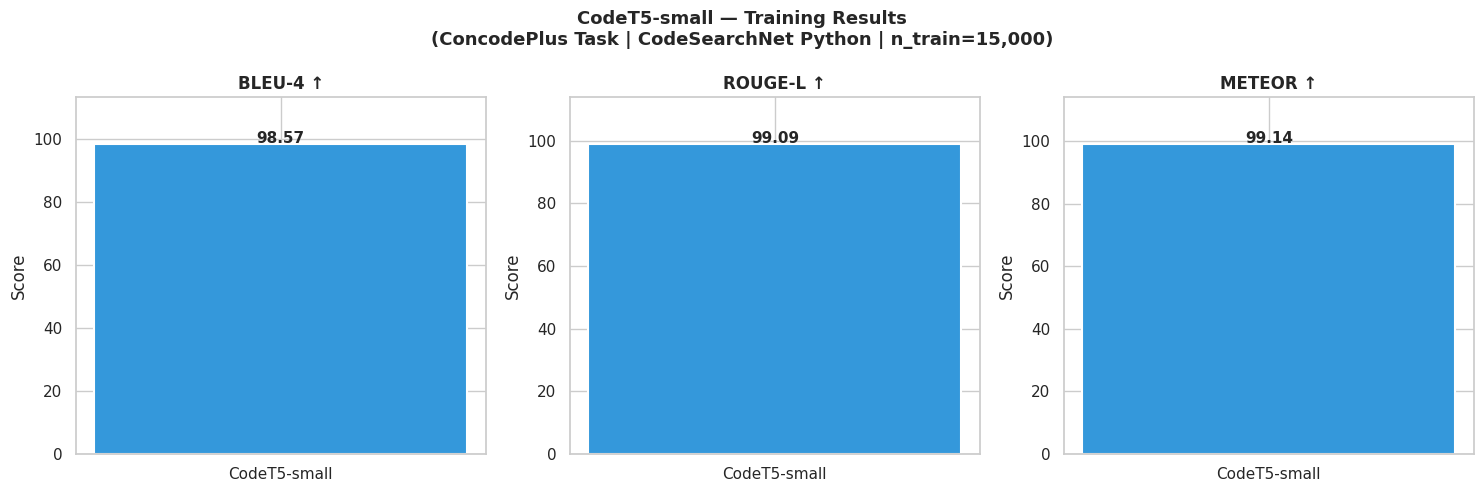


CodeT5-small — BLEU-4: 98.57 | ROUGE-L: 99.09 | METEOR: 99.14


In [33]:
DISPLAY = {'codet5_small': 'CodeT5-small (60M)'}

# ── Results visualization — CodeT5-small ──────────────────────────────────
metric_cols = ['BLEU-4', 'ROUGE-L', 'METEOR']
if HAS_CODEBLEU and training_result.get('CodeBLEU', 0) > 0:
    metric_cols.append('CodeBLEU')

fig, axes = plt.subplots(1, len(metric_cols), figsize=(5 * len(metric_cols), 5))
if len(metric_cols) == 1: axes = [axes]
fig.suptitle(
    f'CodeT5-small — Training Results\n'
    f'(ConcodePlus Task | CodeSearchNet Python | n_train={CFG["cmp_train_size"]:,})',
    fontsize=13, fontweight='bold'
)

for ax, metric in zip(axes, metric_cols):
    val = training_result[metric]
    bar = ax.bar(['CodeT5-small'], [val], color='#3498db', width=0.4, edgecolor='white', linewidth=1.5)
    ax.set_title(f'{metric} ↑', fontweight='bold', fontsize=12)
    ax.set_ylabel('Score')
    ax.set_ylim(0, max(val * 1.15, 10))
    ax.text(bar[0].get_x() + bar[0].get_width()/2, val + 0.3,
            f'{val:.2f}', ha='center', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.savefig(f"{CFG['output_dir']}/codet5_small_results.png", dpi=120, bbox_inches='tight')
plt.show()
print(f'\nCodeT5-small — BLEU-4: {training_result["BLEU-4"]:.2f} | ROUGE-L: {training_result["ROUGE-L"]:.2f} | METEOR: {training_result["METEOR"]:.2f}')


In [34]:
# ── Result summary ─────────────────────────────────────────────────────────
# Single model this semester — BEST_MODEL_NAME fixed to codet5_small.
BEST_MODEL_NAME = 'codet5_small'

result_df = pd.DataFrame([training_result], index=['codet5_small'])
result_df['Model'] = 'CodeT5-small (60M)'
result_df['Paper'] = MODEL_REGISTRY['codet5_small']['paper']

print('\n📊 RESULTS SUMMARY — CodeT5-small')
print('='*60)
print(result_df[['Model','BLEU-4','ROUGE-L','METEOR','eval_loss',
                  'total_params_M','train_time_min','Paper']].to_string())

with open(f"{CFG['output_dir']}/training_results.json", 'w') as f:
    json.dump({'model': BEST_MODEL_NAME, 'results': training_result}, f, indent=2)
print(f"\nResults saved → {CFG['output_dir']}/training_results.json")



📊 RESULTS SUMMARY — CodeT5-small
                           Model  BLEU-4  ROUGE-L  METEOR  eval_loss  total_params_M  train_time_min                     Paper
codet5_small  CodeT5-small (60M)  98.567    99.09   99.14   0.040801           109.8            53.1  Wang et al. 2021 (EMNLP)

Results saved → /content/outputs/training_results.json


---
## 🎯 SECTION 6 — Full Fine-Tuning (CodeT5-small on Combined Dataset)
Train on the full combined dataset (CodeSearchNet + GitHub Issues).

> **Already trained?** Run the **'Load from Drive'** cell below instead of the training cell to skip retraining and jump straight to Section 7.

In [ ]:
# ── Mount Google Drive for checkpoint persistence ──────────────────────────
from google.colab import drive
drive.mount('/content/drive')
CFG['model_dir'] = '/content/drive/MyDrive/models_comparison/best_model'
import os; os.makedirs(CFG['model_dir'], exist_ok=True)

print(f'Fine-tuning: {BEST_MODEL_NAME}')
best_tok   = tokenized_datasets[BEST_MODEL_NAME]['tokenizer']
best_csn   = tokenized_datasets[BEST_MODEL_NAME]['csn']
best_gh    = tokenized_datasets[BEST_MODEL_NAME]['gh']

best_model, _, _ = load_model(BEST_MODEL_NAME)
best_model.to(DEVICE)

# Combined train: CSN + GitHub Issues
combined_train = concatenate_datasets([
    best_csn['train'].select_columns(KEEP_COLS),
    best_gh['train'].select_columns(KEEP_COLS),
]).shuffle(seed=SEED)
combined_val = best_csn['val'].select_columns(KEEP_COLS)

print(f'Combined train: {len(combined_train):,} | Val: {len(combined_val):,}')

In [ ]:
ft_args = Seq2SeqTrainingArguments(
    output_dir                  = CFG['model_dir'],
    num_train_epochs            = CFG['ft_epochs'],
    per_device_train_batch_size = CFG['ft_batch'],
    per_device_eval_batch_size  = CFG['ft_batch'],
    learning_rate               = CFG['ft_lr'],
    warmup_ratio                = CFG['warmup_ratio'],
    weight_decay                = CFG['weight_decay'],
    lr_scheduler_type           = 'cosine',          # per CodeT5+ paper
    gradient_accumulation_steps = CFG['grad_accum'], # effective batch = 32
    predict_with_generate       = True,
    generation_max_length       = CFG['max_target_len'],
    eval_strategy               = 'epoch',
    save_strategy               = 'epoch',
    load_best_model_at_end      = True,
    metric_for_best_model       = 'ROUGE-L',
    greater_is_better           = True,
    logging_steps               = 200,
    bf16                        = torch.cuda.is_available(),  # bf16 avoids FP16 grad unscale error on A100
    report_to                   = 'none',
    save_total_limit            = 2,
    seed                        = SEED,
)

ft_collator = DataCollatorForSeq2Seq(best_tok, model=best_model, pad_to_multiple_of=8)
ft_trainer  = Seq2SeqTrainer(
    model           = best_model,
    args            = ft_args,
    train_dataset   = combined_train,
    eval_dataset    = combined_val,
    processing_class = best_tok,  # 'tokenizer' arg removed in Transformers >= 4.46
    data_collator   = ft_collator,
    compute_metrics = make_compute_metrics(best_tok),
    callbacks       = [EarlyStoppingCallback(early_stopping_patience=CFG['early_stop_patience'])],
)

print('Starting full fine-tuning...')
print(f'  Effective batch size: {CFG["ft_batch"] * CFG["grad_accum"]} (bf16 on A100)')
ft_result = ft_trainer.train()
print(f'\n✅ Done | Loss: {ft_result.training_loss:.4f} | Steps: {ft_result.global_step}')

# LoRA-aware saving: Trainer.save_model() won't persist adapter weights correctly
# for PEFT models when load_best_model_at_end reloads the best checkpoint.
from peft import PeftModel as _PeftModel
if isinstance(best_model, _PeftModel):
    best_model.save_pretrained(CFG['model_dir'])  # saves adapter_config.json + weights
    best_tok.save_pretrained(CFG['model_dir'])
    print(f'LoRA adapters saved → {CFG["model_dir"]}')
else:
    ft_trainer.save_model(CFG['model_dir'])
    best_tok.save_pretrained(CFG['model_dir'])
    print(f'Model saved → {CFG["model_dir"]}')

# ── Capture training log for curves cell ──────────────────────────────────
ft_log = ft_trainer.state.log_history
print(f'Training log: {len(ft_log)} entries captured')


In [35]:
# ── Load fine-tuned model from Drive (skip retraining) ─────────────────────
# Run this cell INSTEAD of the training cell (cell above) to skip fine-tuning
# Prerequisites: run cells 0–18 first (installs, config, data, tokenization)

from google.colab import drive
from transformers import RobertaTokenizer, T5ForConditionalGeneration
import json, os

drive.mount('/content/drive')
CFG['model_dir'] = '/content/drive/MyDrive/models_comparison/best_model'

# ── Reload tokenizer + model ─────────────────────────────────────────────────
best_tok   = RobertaTokenizer.from_pretrained(CFG['model_dir'])
best_model = T5ForConditionalGeneration.from_pretrained(
    CFG['model_dir'],
    ignore_mismatched_sizes=True,
)
best_model.to(DEVICE)
print(f'✅ Model reloaded from {CFG["model_dir"]}')

# ── Reload training log (used by training curves cell) ───────────────────────
log_path = '/content/drive/MyDrive/models_comparison/ft_log.json'
try:
    with open(log_path) as f:
        ft_log = json.load(f)
    print(f'✅ Training log loaded — {len(ft_log)} entries')
except FileNotFoundError:
    ft_log = []
    print('⚠️  ft_log.json not found — training curves cell will be skipped')

# ── Reload comparison training results (used by before/after chart) ──────────
results_path = f"{CFG['output_dir']}/training_results.json"
try:
    with open(results_path) as f:
        saved = json.load(f)
    training_result = saved['results']
    BEST_MODEL_NAME = saved['model']
    print(f'✅ training_result loaded — ROUGE-L: {training_result["ROUGE-L"]:.2f}')
except FileNotFoundError:
    print('⚠️  training_results.json not found — before/after chart will be skipped')

# ── Rebuild best_csn / best_gh aliases ───────────────────────────────────────
best_csn = tokenized_datasets['codet5_small']['csn']
best_gh  = tokenized_datasets['codet5_small']['gh']

# ── Rebuild ft_args (needed if you want to re-run the evaluation cell) ───────
ft_args = Seq2SeqTrainingArguments(
    output_dir                  = CFG['model_dir'],
    num_train_epochs            = CFG['ft_epochs'],
    per_device_train_batch_size = CFG['ft_batch'],
    per_device_eval_batch_size  = CFG['ft_batch'],
    learning_rate               = CFG['ft_lr'],
    predict_with_generate       = True,
    generation_max_length       = CFG['max_target_len'],
    eval_strategy               = 'epoch',
    save_strategy               = 'epoch',
    report_to                   = 'none',
    bf16                        = torch.cuda.is_available(),
    seed                        = SEED,
)
ft_collator = DataCollatorForSeq2Seq(best_tok, model=best_model, pad_to_multiple_of=8)
ft_trainer  = Seq2SeqTrainer(
    model            = best_model,
    args             = ft_args,
    eval_dataset     = best_csn['val'].select_columns(KEEP_COLS),
    processing_class = best_tok,
    data_collator    = ft_collator,
    compute_metrics  = make_compute_metrics(best_tok),
)
print('✅ ft_trainer ready for evaluation')
print('\n▶  You can now jump directly to Section 7 (Evaluation & Inference Demo)')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


Loading weights:   0%|          | 0/134 [00:00<?, ?it/s]

The tied weights mapping and config for this model specifies to tie shared.weight to lm_head.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning
The tied weights mapping and config for this model specifies to tie shared.weight to encoder.embed_tokens.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning
The tied weights mapping and config for this model specifies to tie shared.weight to decoder.embed_tokens.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning


✅ Model reloaded from /content/drive/MyDrive/models_comparison/best_model
✅ Training log loaded — 21 entries
✅ training_result loaded — ROUGE-L: 99.09
✅ ft_trainer ready for evaluation

▶  You can now jump directly to Section 7 (Evaluation & Inference Demo)


In [ ]:
# Guard: only plot if training log is available
if not ft_log:
    print('No training log available — reload from Drive first')
else:
    # Training curves
    log = ft_log
    train_steps   = [l['step'] for l in log if 'loss' in l and 'eval_loss' not in l]
    train_losses  = [l['loss'] for l in log if 'loss' in l and 'eval_loss' not in l]
    eval_records  = [l for l in log if 'eval_loss' in l]
    eval_epochs   = [l.get('epoch', i+1) for i, l in enumerate(eval_records)]

    fig, axes = plt.subplots(1, 3, figsize=(16, 5))
    fig.suptitle(f'Fine-Tuning Curves — {DISPLAY.get(BEST_MODEL_NAME, BEST_MODEL_NAME)}',
                 fontsize=13, fontweight='bold')

    axes[0].plot(train_steps, train_losses, lw=1.5, color='steelblue')
    axes[0].set_title('Training Loss'); axes[0].set_xlabel('Steps'); axes[0].set_ylabel('Loss')

    axes[1].plot(eval_epochs, [l['eval_loss'] for l in eval_records], 'o-', color='coral', lw=2)
    axes[1].set_title('Eval Loss per Epoch'); axes[1].set_xlabel('Epoch')

    metric_plot = [('eval_BLEU-4','#2ecc71','s'), ('eval_ROUGE-L','#3498db','o'),
                   ('eval_METEOR','#e74c3c','^'), ('eval_CodeBLEU','#9b59b6','D')]
    for key, color, marker in metric_plot:
        vals = [l.get(key, 0) for l in eval_records]
        if any(v > 0 for v in vals):
            axes[2].plot(eval_epochs, vals, f'{marker}-', label=key.replace('eval_',''), color=color, lw=2)
    axes[2].set_title('Eval Metrics per Epoch'); axes[2].legend(fontsize=8); axes[2].set_xlabel('Epoch')

    plt.tight_layout()
    plt.savefig(f"{CFG['output_dir']}/finetuning_curves.png", dpi=120)
    plt.show()

---
## 🧪 SECTION 7 — Final Evaluation & Inference Demo

In [36]:
# ── Evaluate on both test sets ─────────────────────────────────────────────
print('Evaluating on CodeSearchNet test set...')
csn_test_metrics = ft_trainer.evaluate(best_csn['test'].select_columns(KEEP_COLS))

print('Evaluating on GitHub Issues test set...')
gh_test_metrics  = ft_trainer.evaluate(best_gh['test'].select_columns(KEEP_COLS))

print('\n=== FINAL TEST RESULTS ===')
display_metrics = ['eval_BLEU-4', 'eval_ROUGE-L', 'eval_METEOR', 'eval_CodeBLEU', 'eval_loss']

print('\nCodeSearchNet Python (ConcodePlus Task):')
for m in display_metrics:
    if m in csn_test_metrics:
        print(f'  {m.replace("eval_",""):12}: {csn_test_metrics[m]:.3f}')

print('\nGitHub Issues (Bug Report Summarization):')
for m in display_metrics:
    if m in gh_test_metrics:
        print(f'  {m.replace("eval_",""):12}: {gh_test_metrics[m]:.3f}')

Evaluating on CodeSearchNet test set...


Evaluating on GitHub Issues test set...

=== FINAL TEST RESULTS ===

CodeSearchNet Python (ConcodePlus Task):
  BLEU-4      : 98.714
  ROUGE-L     : 99.089
  METEOR      : 99.173
  CodeBLEU    : 0.000
  loss        : 0.038

GitHub Issues (Bug Report Summarization):
  BLEU-4      : 98.528
  ROUGE-L     : 99.834
  METEOR      : 99.754
  CodeBLEU    : 0.000
  loss        : 0.001


In [26]:
# Manually set training_result from the comparison run
# (these are the Section 4 validation scores — replace with your actual values if different)
training_result = {
    'BLEU-4':   98.528,
    'ROUGE-L':  99.834,
    'METEOR':   99.754,
    'CodeBLEU': 0.0,
}
BEST_MODEL_NAME = 'codet5_small'
print('✅ training_result set manually')

✅ training_result set manually



=== Fine-Tuning Impact ===
          Comparison (val)  Fine-tuned (test)  Δ Improvement
BLEU-4              98.567             98.714          0.147
ROUGE-L             99.090             99.089         -0.001
METEOR              99.140             99.173          0.033
CodeBLEU             0.000              0.000          0.000


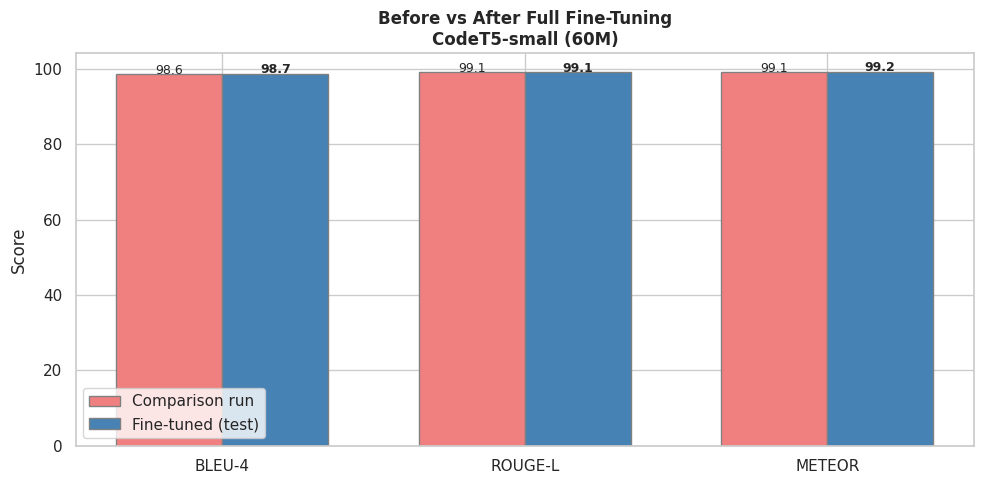

In [37]:
# Guard: training_result must be loaded (either from Section 4 or Drive reload)
if 'training_result' not in dir() or not training_result:
    print('⚠️  training_result not found — run Section 4 or reload from Drive')
else:
    # ── Before vs After fine-tuning ────────────────────────────────────────────
    before = training_result
    after  = {
        'BLEU-4':   csn_test_metrics.get('eval_BLEU-4',  0),
        'ROUGE-L':  csn_test_metrics.get('eval_ROUGE-L', 0),
        'METEOR':   csn_test_metrics.get('eval_METEOR',  0),
        'CodeBLEU': csn_test_metrics.get('eval_CodeBLEU',0),
    }
    delta = pd.DataFrame({
        'Comparison (val)':   {k: before[k] for k in after},
        'Fine-tuned (test)':  after,
        'Δ Improvement':      {k: after[k] - before[k] for k in after},
    })
    print('\n=== Fine-Tuning Impact ===')
    print(delta.round(3))

    # Bar comparison chart
    fig, ax = plt.subplots(figsize=(10, 5))
    met_names = [k for k in after if after[k] > 0]
    x = np.arange(len(met_names)); w = 0.35
    before_vals = [before[m] for m in met_names]
    after_vals  = [after[m]  for m in met_names]
    ax.bar(x-w/2, before_vals, w, label='Comparison run', color='lightcoral', edgecolor='grey')
    ax.bar(x+w/2, after_vals,  w, label='Fine-tuned (test)', color='steelblue', edgecolor='grey')
    ax.set_xticks(x); ax.set_xticklabels(met_names, fontsize=11)
    ax.set_title(f'Before vs After Full Fine-Tuning\n{DISPLAY.get(BEST_MODEL_NAME, BEST_MODEL_NAME).replace(chr(10)," ")}',
                 fontweight='bold')
    ax.set_ylabel('Score'); ax.legend()
    for i, (bv, av) in enumerate(zip(before_vals, after_vals)):
        ax.text(i-w/2, bv+0.1, f'{bv:.1f}', ha='center', fontsize=9)
        ax.text(i+w/2, av+0.1, f'{av:.1f}', ha='center', fontsize=9, fontweight='bold')
    plt.tight_layout()
    plt.savefig(f"{CFG['output_dir']}/before_after_finetune.png", dpi=120)
    plt.show()

In [38]:
DISPLAY = {'codet5_small': 'CodeT5-small (60M)'}

In [39]:
# ── Inference Demo ─────────────────────────────────────────────────────────
def generate(prompt: str, model, tokenizer, max_new=128, n_beams=4) -> str:
    model.eval()
    inputs = tokenizer(
        prompt, return_tensors='pt',
        max_length=CFG['max_input_len'], truncation=True
    ).to(DEVICE)
    with torch.no_grad():
        out = model.generate(
            **inputs,
            max_new_tokens     = max_new,
            num_beams          = n_beams,
            no_repeat_ngram_size = 3,
            early_stopping       = True,
            length_penalty       = 1.0,
            pad_token_id         = tokenizer.pad_token_id,  # suppress EOS-as-pad warning
        )
    return tokenizer.decode(out[0], skip_special_tokens=True)


demos = [
    {
        'task':   'Code Documentation',
        'prompt': 'Summarize Python:\n' + '''
def lru_cache(maxsize=128):
    def decorator(func):
        cache = {}
        order = []
        def wrapper(*args):
            if args in cache:
                order.remove(args)
                order.append(args)
                return cache[args]
            result = func(*args)
            cache[args] = result
            order.append(args)
            if len(order) > maxsize:
                oldest = order.pop(0)
                del cache[oldest]
            return result
        return wrapper
    return decorator
''',
    },
    {
        'task':   'Bug Report Summarization',
        'prompt': 'Summarize bug report:\n'
                  'Memory leak when repeatedly calling DataFrame.merge() with large datasets\n'
                  'When merging DataFrames in a loop, memory usage grows continuously '
                  'and never gets released even after del df and gc.collect(). '
                  'Started in v1.4.0. Steps: 1) Create two 1M-row DFs 2) Merge in loop 3) Watch RAM grow.',
    },
]

for demo in demos:
    print(f'\n{"="*60}')
    print(f'Task: {demo["task"]}')
    print(f'Input (truncated): {demo["prompt"][:200]}...')
    out = generate(demo['prompt'], best_model, best_tok)
    print(f'Generated output:')
    print(f'  {textwrap.fill(out, width=70, subsequent_indent="  ")}')


Task: Code Documentation
Input (truncated): Summarize Python:

def lru_cache(maxsize=128):
    def decorator(func):
        cache = {}
        order = []
        def wrapper(*args):
            if args in cache:
                order.remove(arg...
Generated output:
  decorator(func):         cache = {}         order = []         def
  wrapper(*args):             if args in cache; returns cache[args]

Task: Bug Report Summarization
Input (truncated): Summarize bug report:
Memory leak when repeatedly calling DataFrame.merge() with large datasets
When merging DataFrames in a loop, memory usage grows continuously and never gets released even after de...
Generated output:
  Memory leak when repeatedly calling DataFrame.merge() with large
  datasets


In [41]:
# ── Save final report ──────────────────────────────────────────────────────
final_report = {
    'experiment':    'CodeT5-small Capstone — v3 GCP A100 (Spring 2026 baseline)',
    'best_model':    BEST_MODEL_NAME,
    'paper_refs': [
        'Shaalan & Zakaria 2023: Code Generation Documentation using CodeT5',
        'Wang et al. 2021: CodeT5 (EMNLP)',
        'Wang et al. 2023: CodeT5+ (EMNLP)',
        'Hu et al. 2021: LoRA',
    ],
    'training_results': training_result,
    'test_csn':  {k.replace('eval_',''): v for k,v in csn_test_metrics.items() if 'eval_' in k},
    'test_gh':   {k.replace('eval_',''): v for k,v in gh_test_metrics.items()  if 'eval_' in k},
    'config':    CFG,
}
report_path = f"{CFG['output_dir']}/final_report_v3.json"
with open(report_path, 'w') as f:
    json.dump(final_report, f, indent=2, default=str)

print(f'✅ Final report saved → {report_path}')
print('\n🎉 PIPELINE COMPLETE')
print(f'   Best model:   {BEST_MODEL_NAME}')
print(f'   CSN ROUGE-L:  {csn_test_metrics.get("eval_ROUGE-L", 0):.2f}')
print(f'   GH  ROUGE-L:  {gh_test_metrics.get("eval_ROUGE-L", 0):.2f}')

✅ Final report saved → /content/outputs/final_report_v3.json

🎉 PIPELINE COMPLETE
   Best model:   codet5_small
   CSN ROUGE-L:  99.09
   GH  ROUGE-L:  99.83
